<div style="text-align: center; color: #007ACC; font-weight: bold; text-decoration: underline; font-size: 24px;">
  <h1>Edinburgh airport project</h1>
</div>


## Plan
1. [Introduction](#I)
2. [Importing libraries and data](#ILD)
3. [Exploratory data analysis](#EDA)
4. [Data pre-processing](#DP)
5. [Wordcloud analysis](#WA)
6. [Topic Modelling](#TM)
- [TF-IDF and Latent dirichlet allocation using Sklearn](#LDA)
- [TF-IDF and Latent dirichlet allocation using Gensim](#G)
- [BERT](#BERT)
    - [Topic Modeling](#TMB)
    - [Sentiment Analysis](#SA)
- [Word2vec and Kmeans](#W2V)
7. [Quick Work about premium services](#PM)
8. [Frequency analysis](#FA)
9. [Conclusion](#C)


## Introduction
<a id="I"></a>

The aim of this project is to gather and analyse feedback from passengers based on their experience at Edinburgh airport. Using natural language processing techniques, in particular topic modelling, we are trying to identify the recurring themes and major concerns of passengers. This approach will enable us to better understand the strengths and areas for improvement of the airport's services, in order to optimise the overall user experience. 

Initially, we will focus on the values in the user feedback column ("do you have any other feedback or suggestion?") and, to a lesser extent, the column on premium services, and then we will carry out a more detailed and precise analysis of the dataframe as a whole (in particular to gain a better understanding of the topics). 

## Import libraries and data
<a id="ILD"></a>

In [1]:
# Standard libraries
import string
import warnings
from collections import Counter
import matplotlib.pyplot as plt

# Data manipulation
import pandas as pd
import numpy as np

# Skimpy for quick data summaries
from skimpy import skim

# Text feature extraction and clustering
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans

# Gensim for topic modeling and word embeddings
import gensim
from gensim.models import KeyedVectors

# pyLDAvis for topic modeling visualization
import pyLDAvis
import pyLDAvis.gensim

# Threading for concurrent execution
from concurrent.futures import ThreadPoolExecutor

# BERT for topic modeling
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Custom functions
import functions as f

# Ignore deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


c:\Users\leoco\Documents\cours\M1\S2\Progra Python\PROJET\.venv\Lib\site-packages\plotly\express\imshow_utils.py:24: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
c:\Users\leoco\Documents\cours\M1\S2\Progra Python\PROJET\.venv\Lib\site-packages\plotly\graph_objs\__init__.py:283: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(ipywidgets.__version__) >= LooseVersion("7.0.0"):
c:\Users\leoco\Documents\cours\M1\S2\Progra Python\PROJET\.venv\Lib\site-packages\plotly\graph_objs\__init__.py:283: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(ipywidgets.__version__) >= LooseVersion("7.0.0"):
c:\Users\leoco\Documents\cours\M1\S2\Progra Python\PROJET\.venv\Lib\site-packages\plotly\graph_objs\__init__.py:283: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version inste

In [2]:
df_com = pd.read_csv("data/customer_survey_responses.csv", sep=",", low_memory=False)

## Exploratory data analysis 
<a id="EDA"></a>

In [3]:
skim(df_com)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 24934  │ │ string      │ 62    │                                                          │
│ │ Number of columns │ 62     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name                        ┃ NA         ┃ NA %       ┃ words per row          ┃ total words        ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │ #                                  │          0 │          0 │                      1 │              24934 │  │
│ │ Overall, were you satisfied with   │          0 │          0 │                      1 │              24934 │  │
│ │ your most recent experience at     │            │            │                        │                    │  │
│ │ Edinburgh Airport?                 │            │            │                        │                    │  │
│ │ Did you arrive into, or depart     │          0 │          0 │                    2.7 │              68111 │  │
│ │ from Edinburgh Airport?            │            │            │                        │                    │  │
│ │ What time (roughly) did you arrive │      10226 │      41.01 │                    1.8 │              44124 │  │
│ │ at Edinburgh Airport for your      │            │            │                        │                    │  │
│ │ *departing *flight                 │            │            │                        │                    │  │
│ │ What country were you travelling   │      20299 │      81.41 │                   0.35 │               8603 │  │
│ │ to?                                │            │            │                        │                    │  │
│ │ Why were you travelling?           │      10882 │      43.64 │                    1.1 │              27558 │  │
│ │ What age group do you fall into?   │          0 │          0 │                    1.5 │              36801 │  │
│ │ What country do you live in?       │       1557 │       6.24 │                    1.2 │              28997 │  │
│ │ When do you think you will fly     │          0 │          0 │                      5 │             123839 │  │
│ │ next from Edinburgh Airport?       │            │            │                        │                    │  │
│ │ How did you get to and/or from the │          0 │          0 │                    3.5 │              88477 │  │
│ │ airport?                           │            │            │                        │                    │  │
│ │ Including yourself, how many       │        251 │       1.01 │                    1.1 │              26673 │  │
│ │ people were in your travel party?  │            │            │                        │                    │  │
│ │ Meet and greet / airport concierge │          0 │          0 │                    1.6 │              40940 │  │
│ │ service                            │            │            │                        │                    │  │
│ │ Luggage porterage                  │          0 │   

In [4]:
f.value_count_df(df_com)  #understanding the variables 
# f.hist_variables(df_com) # if you want to make it more visual 

column 1 ----- ['Yes' 'No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    21806
No      3128
Name: count, dtype: int64 

column 2 ----- ['Departed and arrived' 'Arrived _only_' 'Departed _only_'] 

Did you arrive into, or depart from Edinburgh Airport?
Departed and arrived    18243
Departed _only_          5562
Arrived _only_           1129
Name: count, dtype: int64 

column 3 ----- ['12:00 - 16:00' '08:00 - 12:00' nan '04:00 - 08:00' '16:00 - 20:00'
 '00:00 - 04:00' '20:00 - 00:00'] 

What time (roughly) did you arrive at Edinburgh Airport for your *departing *flight
08:00 - 12:00    4198
12:00 - 16:00    3828
04:00 - 08:00    3192
16:00 - 20:00    2482
00:00 - 04:00     538
20:00 - 00:00     470
Name: count, dtype: int64 

column 4 ----- ['Ireland' 'Spain' nan 'France' 'Switzerland' 'Austria'
 'United Kingdom (UK)' 'Czechia' 'Netherlands' 'Belgium' 'Malta' 'Norway'
 'Lithuania' 'Germany' 'Australia' 'Iceland' 'South Africa' 'Philippines

(57, 'columns were printed ')

## Data pre-processing 
<a id="DP"></a>

We create 2 dataframes one about feedbacks (df_com_58) and one about premium services (df_com_59)

Creation

In [5]:
df_com_58_init = df_com.iloc[:,[1,58]]
print (df_com_58_init.shape)

df_com_59_init = df_com.iloc[:,[1,59]]
print (df_com_59_init.shape)

# Création de copies
df_com_58 = df_com_58_init.copy()
df_com_59 = df_com_59_init.copy()

(24934, 2)
(24934, 2)


Rename 

In [6]:
df_com_58.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback'}, inplace=True) #rename the column 
df_com_59.rename(columns={'Are there any other premium services that you would like to see introduced at Edinburgh?': 'services'}, inplace=True) #rename the column 


In [7]:
df_com_58.Feedback = df_com_58.Feedback.astype(str) #to be able to calculate the length of the dataframe 
df_com_59.services = df_com_59.services.astype(str) #to be able to calculate the length of the dataframe 

Delete missing values and useless comments (NaN, "ok", "no", ...): 

In [8]:
df_com_58["Feedback"] = df_com_58["Feedback"].apply(f.few_cara)
df_com_58 = df_com_58[df_com_58['Feedback'] != 'NaN']  #dropna method not working well here 
print(df_com_58.shape)   

df_com_59["services"] = df_com_59["services"].apply(f.few_cara)
df_com_59 = df_com_59[df_com_59['services'] != 'NaN']  #dropna method not working well here 
print(df_com_59.shape)   

(6941, 2)
(2295, 2)


Traduction (translate everything into english)

In [10]:
#sometimes the code doesn't work the first time, just run it again 

executor = ThreadPoolExecutor()  #for running tasks in parallel

# Apply the translation function to the 'Feedback' and 'services' columns 
translated_feedback = list(executor.map(f.trad, df_com_58['Feedback']))
translated_services = list(executor.map(f.trad, df_com_59['services']))

executor.shutdown()

# Create a new column in each DataFrame with the translations
df_com_58['Translated_Feedback'] = translated_feedback
df_com_59['Translated_services'] = translated_services


Cleaning et preparing text for topic modeling

In [11]:
df_com_58['Feedback_treated'] = df_com_58['Translated_Feedback'].apply(f.clean_text)
df_com_59['services_treated'] = df_com_59['Translated_services'].apply(f.clean_text)

## Wordcloud Analysis 
<a id="WA"></a>

Separate positive and negative comments in each dataframe 

In [12]:
#Feedback df 

#positive overall feedback 
com_pos = df_com_58[df_com_58["Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " ] == 'Yes']
print(com_pos.shape)
#negative overall feedback
com_neg = df_com_58[df_com_58["Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " ] == 'No']
print(com_neg.shape)

print("----------------------------------------")
#services df 

#positive overall feedback 
com_pos2 = df_com_59[df_com_59["Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " ] == 'Yes']
print(com_pos.shape)
#negative overall feedback
com_neg2 = df_com_59[df_com_59["Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " ] == 'No']
print(com_neg.shape)

(4869, 4)
(2072, 4)
----------------------------------------
(4869, 4)
(2072, 4)


Feedback Wordclouds

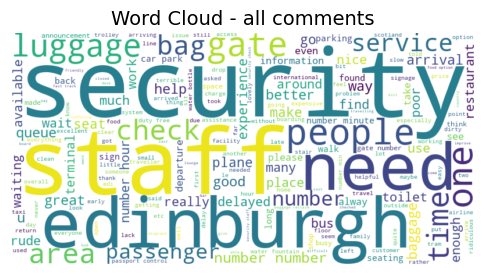

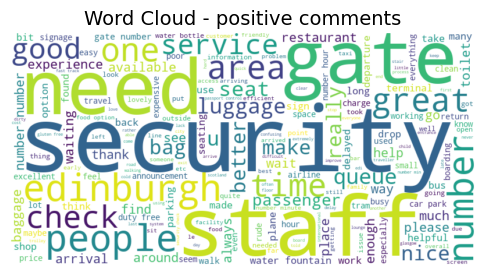

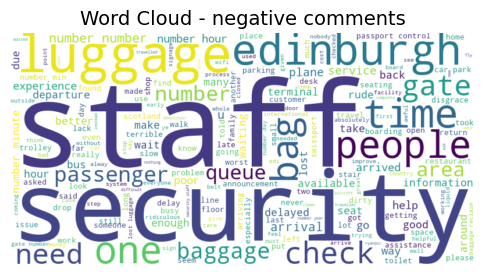

In [13]:
dataframes_titles = [
    (df_com_58['Feedback_treated'], 'Word Cloud - all comments'),
    (com_pos['Feedback_treated'], 'Word Cloud - positive comments'),
    (com_neg['Feedback_treated'], 'Word Cloud - negative comments')]

for dataframe, title in dataframes_titles:
    f.generate_wordcloud(dataframe, title)

Services Wordclouds 

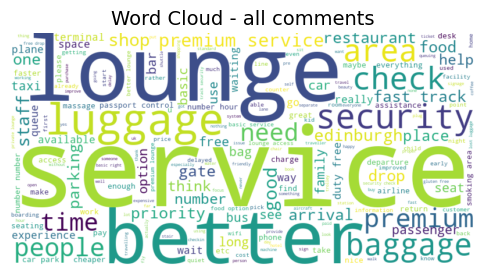

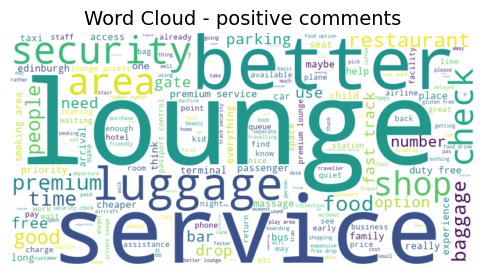

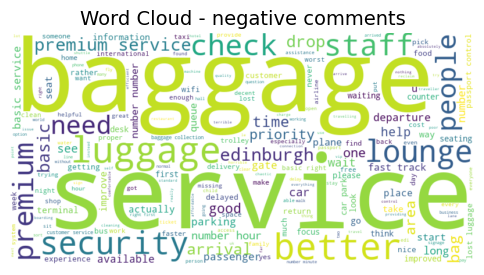

In [14]:
dataframes_titles2 = [
    (df_com_59['services_treated'], 'Word Cloud - all comments'),
    (com_pos2['services_treated'], 'Word Cloud - positive comments'),
    (com_neg2['services_treated'], 'Word Cloud - negative comments')]

for dataframe, title in dataframes_titles2:
    f.generate_wordcloud(dataframe, title)
    

## Topic modeling
<a id="TM"></a>

In this section we use different topic modelling methods and/or different libraries. Some methods are based on the pre-processing carried out in the previous section, while others have their own pre-processing. 

### TF-IDF and Latent Dirichlet Allocation using Sklearn 
<a id="LDA"></a>

TF-IDF (unigrams vs unigrams and bigrams)

In [15]:
features1, vectorizer1 = f.generate_TFIDF(df_com_58['Feedback_treated'], (1,1)) #unigrams
features2, vectorizer2 = f.generate_TFIDF(df_com_58['Feedback_treated'], (1,2)) #unigrams and bigrams

print("Dimensions de la matrice de caractéristiques :", features1.shape)
print("Dimensions de la matrice de caractéristiques :", features2.shape)

Dimensions de la matrice de caractéristiques : (6941, 7318)
Dimensions de la matrice de caractéristiques : (6941, 68126)


LDA 

In [16]:
LDA1 = f.generate_LDA(8, features1, vectorizer1, 20, randomstate=0)
LDA2 = f.generate_LDA(8, features2, vectorizer2, 20, randomstate=0)

print ('Unigrams results are: \n', LDA1, '\n \n Unigrams and bigrams results are: \n', LDA2)

Unigrams results are: 
 Topic 0: great option food gluten free vegan happy experience lounge restaurant please service would bar overall choice available visit affordable
Topic 1: water drop fountain station point bottle charging charge expensive pick refill phone would area free find plug parking smoking nice
Topic 2: baggage luggage toilet arrival get time long staff need security wait queue bus people check car
Topic 3: staff friendly everything car lovely helpful great security experience easy park best good quick fast parking excellent announcement
Topic 4: security control passport queue time luggage long check staff get waiting gate hour area bag need
Topic 5: keep good work love food would experience satisfied overall pleasant great security option halal congested greggs area small people
Topic 6: gate staff security information assistance hour boarding would time check help rude people delayed one bag get
Topic 7: seat security good seating check uncomfortable comfortable expe

To better understand topics 

In [17]:
df_filtre_fountains = df_com_58[df_com_58['Feedback'].str.contains("fountain", case=False)]
df_filtre_security = df_com_58[df_com_58['Feedback'].str.contains("security", case=False)]
df_filtre_staff = df_com_58[df_com_58['Feedback'].str.contains("staff", case=False)]
df_filtre_affordable = df_com_58[df_com_58['Feedback'].str.contains("affordable", case=False)]
df_filtre_expensive = df_com_58[df_com_58['Feedback'].str.contains("expensive", case=False)]
df_filtre_parking = df_com_58[df_com_58['Feedback'].str.contains("parking", case=False)]
df_filtre_seat = df_com_58[df_com_58['Feedback'].str.contains("seat", case=False)]
df_filtre_boarding = df_com_58[df_com_58['Feedback'].str.contains("boarding", case=False)]
df_filtre_information = df_com_58[df_com_58['Feedback'].str.contains("information", case=False)]
df_filtre_gate = df_com_58[df_com_58['Feedback'].str.contains("gate", case=False)]

Looking at the recurring topics and themes, we can draw the following conclusions (1st LDA): 
- topic 0 deals with consumer services (people want to be able to eat gluten-free or vegetarian food) at more affordable prices 
- topic 2 seems to be about long waits to check in luggage, wait for the bus and access the toilets 
- topic 3 contains positive comments about a good experience, including positive feedback about the airport staff (security, etc...)
- topic 4 is similar to topic 2 in terms of interpretation, and deals with lengthy checks and check-ins. 
- topic 5 is a mix of topics covered by topic 0 and topic 3, with positive feedback on consumer services 
- topic 6 deals with problems relative to gates in part
- topic 7 gives feedback on seat comfort and the wifi connection in particular 


### TF-IDF and Latent Dirichlet Allocation using Gensim  
<a id="G"></a>

Lemmatization

In [18]:
df_com_58['lemmatized_column_gensim'] = f.lemmatization(df_com_58['Translated_Feedback'])

Tokenization, delete special characters

In [19]:
df_com_58["data_words_column"] = f.gen_words(df_com_58['lemmatized_column_gensim'])

Bigrams and trigrams

In [20]:
#BIGRAMS AND TRIGRAMS
bigram_phrases = gensim.models.Phrases(df_com_58["data_words_column"], min_count=5, threshold=5)
trigram_phrases = gensim.models.Phrases(bigram_phrases[df_com_58["data_words_column"]], threshold=5)

bigram = gensim.models.phrases.Phraser(bigram_phrases)
trigram = gensim.models.phrases.Phraser(trigram_phrases)

#dataframe with unigrams, bigrams
data_bigrams = f.make_bigrams(df_com_58["data_words_column"], bigram)
#dataframe with unigrams, bigrams and trigrams
data_bigrams_trigrams = f.make_trigrams(data_bigrams, bigram, trigram) 

TF-IDF

In [21]:
corpus, words, texts, id2word = f.process_corpus(data_bigrams_trigrams)

We tried a gridsearch but the modeling associated with were not clear :

In [22]:
# parameters to test 
param_grid = {
    'num_topics': [4, 5]  #[4, 5, 6, 7, 8, 9, 15, 20]
}

# apply the gridsearch 
best_model, best_coherence = f.grid_search_lda(corpus, texts, id2word, param_grid)

# print best parameters 
print("Best LDA model parameters :")
print("Number of subjects :", best_model.num_topics)
print("Alpha :", best_model.alpha)
print("Eta :", best_model.eta)
print("Consistency of subjects :", best_coherence)


Best LDA model parameters :
Number of subjects : 4
Alpha : [0.25 0.25 0.25 0.25]
Eta : [0.25 0.25 0.25 ... 0.25 0.25 0.25]
Consistency of subjects : 0.6685064465636327


Training LDA model and visualization 

In [23]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=4,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha="auto")

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=15)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.346331  0.096104       1        1  39.089438
1      0.105763  0.322558       2        1  27.408251
2      0.322595 -0.107849       3        1  18.117752
0     -0.082026 -0.310814       4        1  15.384559, topic_info=          Term         Freq        Total Category  logprob  loglift
41     airport  1693.000000  1693.000000  Default  15.0000  15.0000
70     luggage   708.000000   708.000000  Default  14.0000  14.0000
79       staff   930.000000   930.000000  Default  13.0000  13.0000
115   security   801.000000   801.000000  Default  12.0000  12.0000
114      queue   509.000000   509.000000  Default  11.0000  11.0000
...        ...          ...          ...      ...      ...      ...
126     really   115.552244   116.226478   Topic4  -4.6896   1.8660
50       never   115.582151   116.256584   Topic4  -4.6894   1.8660
386      stand   108.720903   109.414274   Topic4  -4.7505   1.8654
828       move   105.101369   105.778220   Topic4  -4.7844   1.8654
1630  passport   109.060242   109.765103   Topic4  -4.7474   1.8654

[83 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
40        4  0.991896    again
41        1  0.999597  airport
166       1  0.999614     area
622       1  0.997148  arrival
72        4  0.998036   arrive
...     ...       ...      ...
54        1  0.998969      use
34        1  0.997751     very
9         1  0.998198     wait
116       2  0.996760     well
322       2  0.997367     work

[74 rows x 3 columns], R=15, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 3, 1])

Even when increasing the number of topics it is difficult to interpret :

In [24]:
lda_model2 = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=10,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha="auto")

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model2, corpus, id2word, mds="mmds", R=15)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.430668 -0.218179       1        1  30.175338
3     -0.108765  0.428354       2        1  18.843669
5     -0.378349  0.229731       3        1  11.951942
0      0.244300 -0.365022       4        1   8.506065
2      0.403503 -0.094902       5        1   7.623342
4      0.348332  0.167244       6        1   6.669691
8      0.173739  0.352148       7        1   6.461869
9     -0.084793 -0.388579       8        1   4.034571
6     -0.188939  0.007153       9        1   3.273417
7      0.021640 -0.117949      10        1   2.460096, topic_info=              Term         Freq        Total Category  logprob  loglift
41         airport  1790.000000  1790.000000  Default  15.0000  15.0000
21            need   645.000000   645.000000  Default  14.0000  14.0000
92            more   777.000000   777.000000  Default  13.0000  13.0000
2              get   910.000000   910.000000  Default  12.0000  12.0000
58          flight   742.000000   742.000000  Default  11.0000  11.0000
...            ...          ...          ...      ...      ...      ...
919           turn    33.921634    34.706481  Topic10  -4.0821   3.6821
1674        depart    33.579071    34.363685  Topic10  -4.0923   3.6819
1516      increase    33.265127    34.049823  Topic10  -4.1017   3.6817
85       different    32.634007    33.418661  Topic10  -4.1208   3.6812
3155  arrival_hall    29.768783    30.553703  Topic10  -4.2127   3.6789

[169 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1102      8  0.976939  absolutely
1103      8  0.991715    actually
984       8  0.977385         add
1092     10  0.985083         age
1153      5  0.992145     airline
...     ...       ...         ...
1342     10  0.973144     way_too
1641      7  0.987435        week
779      10  0.988314     welcome
116       1  0.997378        well
1059      8  0.992496       whole

[158 rows x 3 columns], R=15, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 6, 1, 3, 5, 9, 10, 7, 8])

We can draw the following conclusions: 
- there seems to be too long a wait to check in (cluster 1) 
- there are not enough seats (cluster 3)
- it can be complicated to get to and from the airport, and there seems to be a problem with parking (clusters 4 and 7) 
- there is feedback on the cleanliness of the toilets, but it's hard to say at this stage whether it's positive or negative (cluster 7)
- there is also a lot of feedback on security, but once again it is difficult to determine the nature of these comments (cluster 1) 

### BERT
<a id="B"></a>

#### BERT Topic Modelling 

In [25]:
docs=df_com_58["Feedback_treated"].tolist()

In [26]:
#Using KeyBERT in order to have less stopwords in the representative words for topics
representation_model = KeyBERTInspired()
topic_model = BERTopic(representation_model=representation_model,language="english")
topics, probs = topic_model.fit_transform(docs)

In [27]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2197,-1_airport_flight_boarding_departure,"[airport, flight, boarding, departure, arrivin...",[arrived ba1446 sun number oct wait luggage ar...
1,0,177,0_luggage_baggage_bag_suitcase,"[luggage, baggage, bag, suitcase, lost, arrive...",[help lost luggage think bag get help find num...
2,1,164,1_edinburgh_airport_glasgow_scotland,"[edinburgh, airport, glasgow, scotland, scotti...","[always good experience edinburgh, find edinbu..."
3,2,159,2_gate_announced_announcement_announcing,"[gate, announced, announcement, announcing, de...","[gate q set gate announced, time gate announce..."
4,3,153,3_charging_charger_charge_plug,"[charging, charger, charge, plug, socket, rech...","[plug charging point, seating phone charging p..."
...,...,...,...,...,...
106,105,11,105_pavement_wheeled_walkway_mobility,"[pavement, wheeled, walkway, mobility, trolley...",[walkway tram bumpy surface make luggage wheel...
107,106,11,106_dispenser_water_bottle_container,"[dispenser, water, bottle, container, toilet, ...","[would love see water dispenser, water bottle ..."
108,107,11,107_bagdrop_bag_easyjet_luggage,"[bagdrop, bag, easyjet, luggage, airline, airp...",[helpful staff easyjet bag drop return luggage...
109,108,11,108_bus_bussing_service_ticket,"[bus, bussing, service, ticket, number, lothia...",[machine collecting bus train ticket service b...


Topic -1 represent the outliers words


Here are the first 5 topics:

In [28]:
topic_model.get_topic(0)

[('luggage', 0.6095856),
 ('baggage', 0.57754934),
 ('bag', 0.43845683),
 ('suitcase', 0.42718545),
 ('lost', 0.3162517),
 ('arrive', 0.28752455),
 ('delivery', 0.2825648),
 ('locker', 0.27755195),
 ('arrived', 0.26734903),
 ('missing', 0.25174305)]

In [29]:
topic_model.get_topic(1)

[('edinburgh', 0.7173353),
 ('airport', 0.5814811),
 ('glasgow', 0.5762442),
 ('scotland', 0.47631943),
 ('scottish', 0.4436394),
 ('flying', 0.33291617),
 ('newcastle', 0.33230394),
 ('travel', 0.3255602),
 ('travelling', 0.2985435),
 ('fly', 0.29513735)]

In [30]:
topic_model.get_topic(2)

[('gate', 0.67045563),
 ('announced', 0.40536875),
 ('announcement', 0.3749727),
 ('announcing', 0.3460628),
 ('delayed', 0.34532762),
 ('announce', 0.33814245),
 ('earlier', 0.28793076),
 ('departure', 0.28669596),
 ('early', 0.27972597),
 ('boarding', 0.27468458)]

In [31]:
topic_model.get_topic(3)

[('charging', 0.67510957),
 ('charger', 0.61029136),
 ('charge', 0.5719073),
 ('plug', 0.42042533),
 ('socket', 0.4193739),
 ('recharging', 0.39855993),
 ('outlet', 0.3985204),
 ('phone', 0.33899426),
 ('spot', 0.3241931),
 ('telephone', 0.32161462)]

In [32]:
topic_model.get_topic(4)

[('baggage', 0.48075885),
 ('delay', 0.43371513),
 ('luggage', 0.4141802),
 ('delayed', 0.40310428),
 ('airline', 0.37349102),
 ('bagage', 0.31658518),
 ('waited', 0.30134827),
 ('bag', 0.29852307),
 ('arrive', 0.27931768),
 ('flight', 0.27869254)]

Let's take a look at the representative documents of those topics:


In [33]:
topic_model.get_representative_docs(0)

['help lost luggage think bag get help find number week arrive got home',
 'lost luggage service bad',
 'staff available lost luggage']

In [34]:
topic_model.get_representative_docs(1)

['always good experience edinburgh',
 'find edinburgh one best airport staff always helpful',
 'edinburgh lot better glasgow airport live glasgow always flown glasgow edinburgh airport flying keep good work edinburgh airport p get family fly edinburgh glasgow']

In [35]:
topic_model.get_representative_docs(2)

['gate q set gate announced',
 'time gate announced quite late sit gate',
 'departure gate set q system gate announced']

In [36]:
topic_model.get_representative_docs(3)


['plug charging point', 'seating phone charging point', 'phone charging point']

In [37]:
topic_model.get_representative_docs(4)

['wait time baggage reclaim way long larger flight u recently waited hour carousel start recent trip number people waiting luggage took hour another international flight arrived waiting luggage arrived within minute first people passing border control never experienced delay baggage reclaim airport feel effort could made improve customer experience give tourist good first impression would go far say felt embarrassed',
 'luggage wait long arrival waited nearly one hour',
 'baggage reclaim extremely slow waited hour']

In [38]:
# Print informations about a sample of documents just to have an idea
doc_topic_info=topic_model.get_document_info(docs)
doc_topic_info.sample(5)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
6313,would nice smoking area,32,32_smoking_smoke_smokeing_smoker,"[smoking, smoke, smokeing, smoker, ashtray, ar...","[need smoking area security, need smoking area...",smoking - smoke - smokeing - smoker - ashtray ...,0.416341,False
1352,airport need spacious general,-1,-1_airport_flight_boarding_departure,"[airport, flight, boarding, departure, arrivin...",[arrived ba1446 sun number oct wait luggage ar...,airport - flight - boarding - departure - arri...,0.000000,False
434,announcing gate 10mins boarding pain many gate...,2,2_gate_announced_announcement_announcing,"[gate, announced, announcement, announcing, de...","[gate q set gate announced, time gate announce...",gate - announced - announcement - announcing -...,0.602368,False
5958,long line security,96,96_line_security_tsa_traffic,"[line, security, tsa, traffic, scanning, barri...","[better line security, long line security, dep...",line - security - tsa - traffic - scanning - b...,1.000000,True
6920,airport check area need lighting also baggage ...,4,4_baggage_delay_luggage_delayed,"[baggage, delay, luggage, delayed, airline, ba...",[wait time baggage reclaim way long larger fli...,baggage - delay - luggage - delayed - airline ...,0.629078,False


Now we add the topics and affiliated probabilities columns to our initial Dataframe 

In [39]:
df_com_58["Topics"]=topics
df_com_58["Clustering_probability"]=probs

In [40]:
df_com_58.sample(5)

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback,Translated_Feedback,Feedback_treated,lemmatized_column_gensim,data_words_column,Topics,Clustering_probability
7195,No,The Ryanair personal was not nice,The Ryanair personal was not nice,ryanair personal nice,personal nice,"[personal, nice]",91,1.00000
3541,Yes,The only problem I have had at the airport is ...,The only problem I have had at the airport is ...,problem airport trying deal ba try route scott...,only problem airport try deal try route scotti...,"[only, problem, airport, try, deal, try, route...",10,0.47747
6831,Yes,Your security personnel are top notch friendly...,Your security personnel are top notch friendly...,security personnel top notch friendly helpful,security personnel top notch friendly helpful,"[security, personnel, top, notch, friendly, he...",50,1.00000
22899,No,improvement is needed for areas before security.,improvement is needed for areas before security.,improvement needed area security,improvement need area security,"[improvement, need, area, security]",-1,0.00000
14611,Yes,Yes the car park long stay prices are ridiculo...,Yes the car park long stay prices are ridiculo...,yes car park long stay price ridiculous cost p...,car park long stay price ridiculous cost more ...,"[car, park, long, stay, price, ridiculous, cos...",-1,0.00000


Topic visualiszation


In [41]:
topic_model.visualize_topics()

We find that even if there is a large number of topics, we can summarize a lot of the information using the first 20 topics (+ or -), since most of the topics found after result from them.


#### BERT Sentiment Analysis 

In [42]:
# Load the pre-trained BERT model
tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

The following cell takes a long time to execute (about 10 minutes for us)

In [43]:
# Creating a score column
df_com_58["Sentiment_score"]=df_com_58["Feedback_treated"].apply(lambda x: f.Sentiment_anlysis(x, tokenizer, model))

In [44]:
df_com_58.sample(10)

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback,Translated_Feedback,Feedback_treated,lemmatized_column_gensim,data_words_column,Topics,Clustering_probability,Sentiment_score
18893,No,Need more seating in downstairs section of ter...,Need more seating in downstairs section of ter...,need seating downstairs section terminal prior...,need more seating downstairs section terminal ...,"[need, more, seating, downstairs, section, ter...",74,0.999088,3
17785,No,"Why are you unload luggage, when its not suppo...","Why are you unload luggage, when its not suppo...",unload luggage supposed checked bll supposed g...,unload luggage suppose check suppose go way un...,"[unload, luggage, suppose, check, suppose, go,...",-1,0.000000,1
3348,Yes,Some people of the security were not friendly...,Some people of the security were not friendly...,people security friendly rude,people security rude,"[people, security, rude]",53,0.608093,1
5136,Yes,Lovely airport!,Lovely airport!,lovely airport,lovely airport,"[lovely, airport]",37,1.000000,5
6535,No,Another way to get to my gate without going th...,Another way to get to my gate without going th...,another way get gate without going shop really...,way get gate go shop ’ really old fashion,"[way, get, gate, go, shop, really, old, fashion]",-1,0.000000,5
7080,No,We were there in the storm and seemed to be a ...,We were there in the storm and seemed to be a ...,storm seemed lot confusion plane take lot peop...,there storm seem lot confusion plane take lot ...,"[there, storm, seem, lot, confusion, plane, ta...",-1,0.000000,2
17696,Yes,It would be good if there were gluten and soy ...,It would be good if there were gluten and soy ...,would good gluten soy free option food many re...,good gluten soy free option food many restuara...,"[good, gluten, soy, free, option, food, many, ...",20,1.000000,3
18979,Yes,"As the ""Gateway to Scotland"" the airport is ol...","As the ""Gateway to Scotland"" the airport is ol...",gateway scotland airport old small,gateway airport old small,"[gateway, airport, old, small]",1,1.000000,4
20702,No,Entry and Exit to airport needs to improve.,Entry and Exit to airport needs to improve.,entry exit airport need improve,entry airport need improve,"[entry, airport, need, improve]",-1,0.000000,3
20211,No,"Our flight was delayed, all restaurants closed...","Our flight was delayed, all restaurants closed...",flight delayed restaurant closed information,flight delay restaurant close information,"[flight, delay, restaurant, close, information]",6,1.000000,1


We will now take a closer look to the repartition of the different scores and what they involve


In [45]:
df_com_58_Yes=df_com_58.loc[df_com_58['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_com_58_No=df_com_58.loc[df_com_58['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [46]:
freq_No = df_com_58_No.groupby(["Sentiment_score"]).count()/len(df_com_58_No['Sentiment_score'])*100
freq_No.drop( ['Feedback', 'Translated_Feedback', 'Feedback_treated'], axis=1, inplace=True)
freq_No.rename(columns={"Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " : "Passenger frequency"}, inplace = True)
freq_No

,Passenger frequency,lemmatized_column_gensim,data_words_column,Topics,Clustering_probability
Sentiment_score,,,,,
1,62.162162,62.162162,62.162162,62.162162,62.162162
2,11.486486,11.486486,11.486486,11.486486,11.486486
3,11.872587,11.872587,11.872587,11.872587,11.872587
4,8.638996,8.638996,8.638996,8.638996,8.638996
5,5.839768,5.839768,5.839768,5.839768,5.839768


BERT sentiment analysis seems to provide consistent results for people who are not satisfied with their experience. Note however that the small proportion of positive comments (4 or 5) refers to comments suggesting the need of improvement for certain services, they are not really positive comments they should have had a score of 3 (neutral) at most.


In [47]:
freq_Yes = df_com_58_Yes.groupby(["Sentiment_score"]).count()/len(df_com_58_Yes['Sentiment_score'])*100
freq_Yes.drop( ['Feedback', 'Translated_Feedback', 'Feedback_treated'], axis=1, inplace=True)
freq_Yes.rename(columns={"Overall, were you satisfied with your most recent experience at Edinburgh Airport?  " : "Passenger frequency"}, inplace = True)
freq_Yes

,Passenger frequency,lemmatized_column_gensim,data_words_column,Topics,Clustering_probability
Sentiment_score,,,,,
1,26.555761,26.555761,26.555761,26.555761,26.555761
2,9.159992,9.159992,9.159992,9.159992,9.159992
3,21.482851,21.482851,21.482851,21.482851,21.482851
4,19.634422,19.634422,19.634422,19.634422,19.634422
5,23.166975,23.166975,23.166975,23.166975,23.166975


For satisfied people, there is a less clear distribution of modalities. This illustrates the fact that many people say they are satisfied with their experience but actually provide a negative or neutral opinion. Among the positive comments (4 and 5), one part refers to suggestions for improving the airport while another part focuses on positive comments on the latter.


__Conclusion SA: Our model seems effective to classify negative comments but has more difficulty to judge neutral comments (suggestion, remark, etc.) by considering them as positive which adds a certain bias in the interpretation of classes 4 and 5.__


In [48]:
#Creating a dataframe with the mean sentiment score per topic
sentiment_per_topic = df_com_58.groupby("Topics").agg({"Sentiment_score" : "mean"})
sentiment_per_topic.sample(5)

,Sentiment_score
Topics,
19,3.893939
79,2.300000
106,3.181818
20,3.292308
103,2.615385


This table can helps us to understand which subjects irritate people the most. 

### Word2vec and Kmeans
<a id="W2V"></a>

Quick pre-processing


In [49]:
df_58_no_nan = df_com_58[['Translated_Feedback']]

# to transform a DataFrame into a Series 
df_58_no_nan = df_58_no_nan.squeeze()

# to reset the index
df_58_no_nan.reset_index(drop=True, inplace=True)

In [50]:
# pre-trained embedding (100-dimensional version to download or the heavier version. WARNING: takes a long time to run (about 10 mins))
wordtovec = KeyedVectors.load_word2vec_format("Fichier_modeles_pre_entraines\enwiki_20180420_100d.txt", binary=False)

In [51]:
# cleaning text 
corpus_clean = f.preprocess_corpus(df_58_no_nan)
print(corpus_clean[:5])

[['weve', 'traveling', 'kid', 'didnt', 'get', 'help', 'spend', 'time', 'long', 'queue', 'checkin', 'kid', 'exhausted', 'wait'], ['taxi', 'situation', 'disaster', 'need', 'black', 'cab', 'rank', 'pick', 'drop', 'charge', 'also', 'shamble', 'tram', 'excess', 'charge', 'also', 'joke', 'come', 'back', 'switzerland', 'quite', 'expensive', 'place', 'eur', 'airport', 'via', 'train', 'show', 'edinburgh', 'airport', 'money', 'grabbing', 'sad'], ['please', 'improve', 'car', 'access', 'car', 'park', 'signage'], ['airport', 'disgrace', 'capital', 'city', 'overstuffed', 'cramped', 'walk', 'car', 'park', 'grim', 'appearance', 'infrastructure', 'terrible', 'look', 'like', 'year', 'past', 'selling', 'date', 'never', 'use'], ['think', 'poor', 'airport', 'wrong', 'information', 'displayed', 'screen', 'time', 'flight', 'would', 'missed', 'flight', 'friend', 'checked', 'gate']]


In [52]:
print("We will work on", len(corpus_clean), "observations after transformation, some of which will be suppressed because they will be zero vectors")
print('vector shape:' , wordtovec.vectors.shape)

We will work on 6941 observations after transformation, some of which will be suppressed because they will be zero vectors
vector shape: (4530030, 100)


In [53]:
# words similar to 'luggage'
print(wordtovec.most_similar(['luggage']))
# 'flight'
print(wordtovec.most_similar(['flight']))

[('baggage', 0.8295016884803772), ('ENTITY/Baggage', 0.7318035364151001), ('suitcases', 0.7243361473083496), ('luggages', 0.719501256942749), ('couchettes', 0.7176079750061035), ('bags', 0.7152078747749329), ('lockable', 0.712124764919281), ('palletised', 0.7077257633209229), ('saddlebags', 0.7059573531150818), ('jumpseats', 0.7058613300323486)]
[('og269', 0.7825520038604736), ('flights', 0.7777429223060608), ('taxiing', 0.7772141098976135), ('takeoff', 0.7710542678833008), ('flying', 0.7625461220741272), ('1030x', 0.7619001269340515), ('lz101', 0.7598139643669128), ('qz8501', 0.7579919099807739), ('boeing', 0.7429320216178894), ('copilot', 0.7378765344619751)]


In [54]:
# process the documents in the corpus corpus
docsVec = list()
# for each document in the cleaned corpus
for doc in corpus_clean:
    # calculate its vector
    vec = f.my_doc_2_vec(doc,wordtovec)
    # add to the list
    docsVec.append(vec)
# transform into a numpy matrix
matVec = np.array(docsVec)

print(matVec.shape)

(6941, 100)


In [55]:
# new database with an associated vector for each comment 
corpus_final = pd.DataFrame(matVec,columns=["v"+str(i+1) for i in range(matVec.shape[1])])

In [56]:
print(df_58_no_nan.shape) # data with our comments in text form 
print(corpus_final.shape) # corpus used to apply the kmeans 
# the number of lines is correct 

(6941,)
(6941, 100)


In [57]:
# 20 defined clusters (for example)
# the choice was made arbitrarily 
num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
corpus_final['cluster'] = kmeans.fit_predict(corpus_final)

In [58]:
# we're going to move the 'cluster' column from 'corpus_final_no_empty' to 'df_58_no_nan'.
df_merged = pd.merge(df_58_no_nan, corpus_final[['cluster']], left_index=True, right_index=True, 
                     how='left', suffixes=('', '_y'))

df_merged.rename(columns={'cluster_y' : 'cluster'}, inplace=True)

df_merged.head(20)

,Translated_Feedback,cluster
0,We've been traveling with 3 kids and we didn't...,1
1,"The taxi situation is a disaster, you need a b...",9
2,Please improve car access and car park signage.,17
3,The airport is a disgrace for a capital city. ...,8
4,"I do think it is very poor, that the airport h...",10
5,The luggage took a long time to come off the a...,19
6,"The KLM counter only opened at 3pm, however st...",9
7,Restaurants closed more than an hour before ou...,10
8,Something else for the recycling element as I ...,11
9,The boarding staff is very rude,14


In [59]:
# display the modalities and frequency of the 'cluster' variable
print(df_merged['cluster'].value_counts())

cluster
9     963
1     923
8     850
11    647
15    418
3     388
10    385
19    329
17    307
14    301
4     260
7     224
0     177
6     140
18    131
2     130
12    109
13    106
16    103
5      50
Name: count, dtype: int64


In [60]:
# the least represented cluster => 5
print(df_merged[df_merged['cluster'] == 5])

                                    Translated_Feedback  cluster
19                      It was great experience overall        5
185                               Everything was great!        5
199                     thanks for scotish hospitallity        5
455                                We had a great time!        5
456   Just keep doing what you guys are doing! Love ...        5
486                It's been great every time I've been        5
509                                Everything was great        5
581                                   Great experience!        5
648                          Thanks, I love Scotland :)        5
733                                Edinburgh was a joy!        5
823               Great experience. Everything was easy        5
845                    Great to see Many power outlets!        5
919                                    Great experience        5
1013                                   Ok for all great        5
1116                     

In [61]:
cluster_comments = {}

# fill the dictionary with text comms for each cluster
for cluster_num in range(num_clusters):
    cluster_comments[cluster_num] = df_merged[df_merged['cluster'] == cluster_num].iloc[:, 0].tolist()

In [62]:
# print 10 comments by cluster
for cluster_num in range(num_clusters) :
    print(f"Groupe {cluster_num} :")
    for i, comment in enumerate(cluster_comments[cluster_num][:10], 1) :
        print(f"{i}. {comment}")
    print("----------")

Groupe 0 :
1. Expensive to pick up drop off
2. To expensive for drop off and pick up and bar prices are far to expensive can’t help thinking you are ripping people off because there are no other options
3. Drop off parking is too expensive. First 10 min. Should be free
4. The drop off and pick up should be easier than now
5. BETTER PRICING ON PARKING
6. The quick drop off price of £5 is abit too much considering my lift doesn’t spend 5 minutes at the airport.
7. Was fine, airport drop off prices and price of food inside airport is extortionate though.
8. Cost cost cost. Cost to park. Cost to eat. Cost to get the bus. I think this is monopoly pricing and squeezing as much profit from the consumer. Prices almost double that to high street for food and drink. Extortionate to park any where near.
9. Parking is very expensive.
10. Car parking price abusive
----------
Groupe 1 :
1. We've been traveling with 3 kids and we didn't get help. We spend time in long queues at check-in, and our kids

In [63]:
# create a dictionary to store summaries/clusters
cluster_summaries = {}

# generate a summary for each cluster
for cluster_num in range(num_clusters):
    # concatenate cluster comms into 1 text
    cluster_text = ' '.join(cluster_comments[cluster_num])
    
    # generate the cluster summary
    summary = f.generate_summary(cluster_text, sentence_count=5) # we can adjust the nb of sentences for each cluster (turn bcp with + sentences)
    cluster_summaries[cluster_num] = summary

# to display cluster summaries
for cluster_num, summary in cluster_summaries.items():
    print(f"Cluster {cluster_num} Summary:")
    print(summary)
    print("----------")

Cluster 0 Summary:
The price is extortionate for a 2 minute drop off The car hire pick up is absurdly far from the terminal! Parking drop off pricing is extortionate Getting to and from the airport continues to be ridiculously hard if you don’t want to spend £20. drop off pick up should be free and easy Not charge £5 for 10 minutes to drop off - ridiculous dropping off and picking up shouldnt cost money Free parking for private Pickups at least 20 min Reduce prices as they are far far too high and unaffordable for many The car parking was rather rather expensive. Reduce the tram fee Lowering price of short term terminal parking Charge for pick up and drop off is very expensive. Signs to the car rental return lot were hard to find Drop off too expensive Car rental return signs were confusing Taxis are extortionate Drop off/pick up fees are too expensive.
----------
Cluster 1 Summary:
One of the handbag handlers (at the conveyer belt taking receipt of the plastic trays) practically rippe

Let's ask ourselves what the optimal number of clusters is to better summarize the information. Let's test the elbow method.

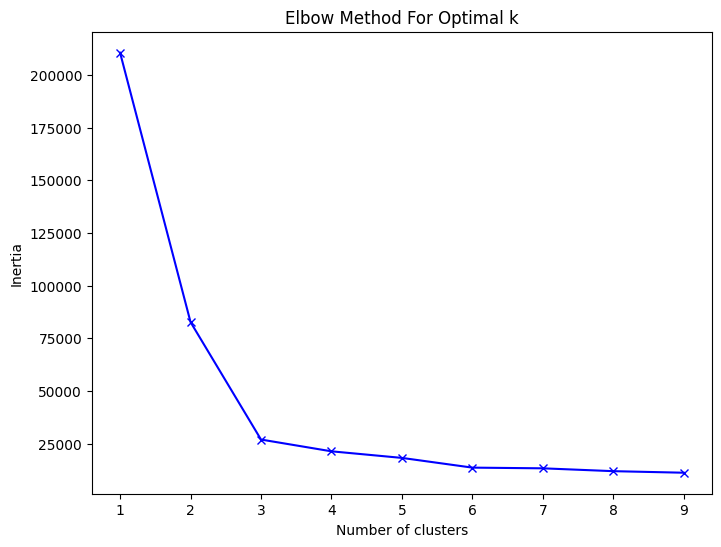

In [64]:
inertias = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(corpus_final)
    inertias.append(kmeans.inertia_)

# plot the inertia curve as a function of the number of clusters
plt.figure(figsize=(8, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

The elbow method suggests 3 clusters, which would result in a large number of observations within each cluster and make interpretation difficult. Therefore, we propose increasing the number of clusters to a reasonable number, such as 20, and examining if themes reoccur within each cluster. If two or more clusters discuss similar topics, we will look to merge them.

__Positive reviews:__  


We will therefore seek to group the clusters that generally address the same issue. For example, Cluster 5 expresses a generally positive experience with mentions of Scottish hospitality, as well as Clusters 6 and 16, which provide a very positive overall opinion.

In [65]:
# create a new column 'cluster_merged' which is a copy of 'cluster'.
df_merged['cluster_merged'] = df_merged['cluster']

# and replace values 5 and 16 with 6 in the new column
df_merged['cluster_merged'] = df_merged['cluster_merged'].replace({5: 6, 16: 6})
print(df_merged['cluster_merged'].value_counts())


cluster_merged
9     963
1     923
8     850
11    647
15    418
3     388
10    385
19    329
17    307
14    301
6     293
4     260
7     224
0     177
18    131
2     130
12    109
13    106
Name: count, dtype: int64


Cluster 6 will include Clusters 5, 6, and 16, thus mostly containing positive feedback about the airport and its services.

__Negative reviews:__


Next, we have Cluster 3 which provides suggestions for improving food options, particularly for children and specific diets, and Cluster 12 expressing a need for more food options for specific diets. Therefore, we will group these two clusters together.

_Cluster 3:_

Suggestions to improve restaurants, amenities like playgrounds and massage chairs, food choices for children and dietary options, cleanliness of restrooms and dining areas.

_Cluster 12:_

Need for more food options for specific diets (gluten-free, vegan, etc.), healthy and affordable food options, and more dietary choices in restaurants and cafes.

In [66]:
# replace the values 12 with 3 in the new column
df_merged['cluster_merged'] = df_merged['cluster_merged'].replace({12: 3})
print(df_merged['cluster_merged'].value_counts())

cluster_merged
9     963
1     923
8     850
11    647
3     497
15    418
10    385
19    329
17    307
14    301
6     293
4     260
7     224
0     177
18    131
2     130
13    106
Name: count, dtype: int64


#### <p style="color: red;">Attention: sometimes the problem still persists with clusters containing multiple themes without necessarily being homogeneous. This is because individuals may propose improvements and express their dissatisfaction on multiple subjects.</p>


_Cluster 0:_

The feedback highlights significant concerns about the high costs associated with dropping off and picking up passengers at the airport. The prices for a 2-minute drop-off are considered extortionate, and the car hire pick-up is inconveniently far from the terminal. Parking fees are similarly high, making it difficult to access the airport without spending a substantial amount. Many believe that drop-off and pick-up should be free and straightforward, with complaints about a £5 charge for a 10-minute drop-off being particularly common. Additionally, the signs to the car rental return lot are confusing, and taxis are deemed excessively expensive. Overall, there's a strong demand for reducing these exorbitant costs.

_Cluster 1:_  
This cluster is quite comprehensive, featuring often lengthy comments that touch on various topics. However, the key points are: 

**Theme:** Customer experience and cleanliness. 
The summary highlights issues with staff, announcements, security, hygiene, general organization, and the overall welcome at Edinburgh Airport. Passengers frequently mention unhelpful or rude staff, confusing or poorly made announcements, and long security queues. Additionally, there are consistent complaints about dirty restrooms and unclean areas in the airport. The lack of organization and insufficient signage further contribute to a negative first impression for travelers arriving at Edinburgh Airport. Overall, these factors significantly impact the customer experience.

_Cluster 2:_  
Many positive reviews mentioning the airport, and sometimes the excessive price to access the airport is mentioned.

_Cluster 3:_  
Suggestions to improve restaurants, amenities like playgrounds and massage chairs, food choices for children and dietary options, cleanliness of restrooms and dining areas.

_Cluster 4:_  
The key issue is potable water, with not enough water fountains. People are unhappy and want free access to drinking water. 'Water' is frequently mentioned in this cluster. Additionally, the toilets are either not clean or insufficient (less frequent), with cleanliness being the main problem. This issue is also present in other clusters.

_Cluster 5:_  
Positive feedback with comments like 'everything is ok' and 'generally good'.

_Cluster 6:_  
Positive feedback with comments like 'everything is ok' and 'generally good'.

_Cluster 7:_   
This cluster highlights issues with long wait times at security and passport control at Edinburgh Airport. There is also a noted lack of seating before the security checkpoints, making the wait even more uncomfortable. The security system itself is described as chaotic and poorly organized, with inconsistent information being provided to travelers. Improving queue management and increasing the number of seats before security are key suggestions from passengers.

_Cluster 8:_  
In this cluster, passengers express a need for better signage throughout the airport to improve navigation. Cleanliness is another major concern, particularly in public areas and restrooms. Some travelers also object to having to pass through duty-free shops, suggesting a more direct route would be preferable. Ensuring clear and effective signage and maintaining high standards of cleanliness are critical areas for improvement according to the feedback.

_Cluster 9:_  
Similar to Cluster 1 (which has the most observations), this cluster remains very broad but gathers complaints on a variety of subjects.

The summary highlights several issues: concessions closing too early, a lack of staff and seating, flight delays, and poor overall organization. Many passengers are frustrated with concessions and shops closing before the end of the day, leaving them without food and shopping options during late hours. There are frequent complaints about insufficient staff to assist travelers and not enough seating areas, especially during busy periods. Additionally, flight delays are a common problem, further exacerbating the lack of organization and leading to a stressful experience for many travelers at the airport.

_Cluster 10:_  
This cluster addresses issues related to flight delays, poor check-in service, and problems with communication of announcements and flight information. Passengers frequently report frustrations with long wait times and inadequate information during delays.

_Cluster 11:_  
This cluster highlights problems with the check-in process, unpleasant chemical odors, a need for more recycling bins, insufficient charging points for electronic devices, and long customs queues. 

_Cluster 12:_  
Need for more food options for specific diets (gluten-free, vegan, etc.), healthy and affordable food options, and more dietary choices in restaurants and cafes.

_Cluster 13:_  
One cluster stands out clearly, **Cluster 13**: Charging Facilities and Wi-Fi. The summary highlights negative feedback on these subjects: a lack of charging points for electronic devices, unreliable Wi-Fi, and a need for more outlets and better charging facilities. The issue of charging points for electronic devices also appears in **Cluster 11** and **Cluster 17**.

_Cluster 14:_  
Many passengers praise the staff for being friendly, helpful, and attentive, particularly in cases requiring special assistance, such as for elderly or disabled travelers. There are several commendations for the swift response to unattended items and the exceptional support from security and customer service personnel. However, there are notable criticisms as well. Some passengers report rude behavior from boarding staff and overzealous security checks, especially concerning personal medications. Additionally, the cleanliness of the toilets is inconsistent. Overall, while the airport staff generally receive high marks for their helpfulness and professionalism, there are areas for improvement in cleanliness, sensitivity during security checks, and overall customer service to ensure a consistently positive experience for all travelers.

_Cluster 15:_  
This cluster identifies issues with long queues, a lack of staff in baggage claim areas, and excessively long passport control lines.

_Cluster 16:_  
Positive feedback with comments like 'everything is ok' and 'generally good'.

_Cluster 17:_  
Passengers often express frustration with having to take buses to distant gates, which adds time and inconvenience to their journey. There is a demand for more seating equipped with USB charging ports

_Cluster 18:_  

For Cluster 18, the main issues include a lack of comfortable seating, too many stairs, and the need for more seats before the boarding gates. Passengers frequently complain about the discomfort of the available seating, particularly the wooden benches which are cold and hard. The shortage of seating in general areas and at gates often leaves travelers standing for extended periods, which is especially challenging for those with mobility issues or during flight delays. Additionally, there are concerns about the limited number of assistance seats at each gate, further exacerbating the problem for elderly or disabled passengers who require more support while waiting.

_Cluster 19:_  

Issues with assistance for disabled individuals, cleanliness of baggage claim areas and restrooms, and the need for more staff at passport control and check-ins.

##### In conclusion, there are numerous issues identified. These problems are not unique to Edinburgh Airport but are common to many airports. It is therefore essential to address these issues based on the resources available to the airport and according to their urgency. It is clear that resolving all the points mentioned is impossible. Prioritizing the most critical and feasible improvements will help enhance the overall passenger experience.

## Quick work about premium services
<a id="PM"></a>

We did not focus on this column because if you look at the database, you will see that the comments do not necessarily refer to the premium services they would like to see in the airport.

In [67]:
features3, vectorizer3 = f.generate_TFIDF(df_com_59['services_treated'], (1,1)) #unigrams
features4, vectorizer4 = f.generate_TFIDF(df_com_59['services_treated'], (1,2)) #unigrams and bigrams

print("Dimensions de la matrice de caractéristiques :", features1.shape)
print("Dimensions de la matrice de caractéristiques :", features2.shape)

Dimensions de la matrice de caractéristiques : (6941, 7318)
Dimensions de la matrice de caractéristiques : (6941, 68126)


In [68]:
LDA1 = f.generate_LDA(8, features3, vectorizer3, 20, randomstate=0)
LDA2 = f.generate_LDA(8, features4, vectorizer4, 20, randomstate=0)

print ('Unigrams results are: \n', LDA1, '\n \n Unigrams and bigrams results are: \n', LDA2)

Unigrams results are: 
 Topic 0: station charging phone nice luggage water return duty collect free baggage everything service find space perfect passenger quiet adult
Topic 1: food option service child basic premium better right get kid play quality first thank family area restaurant choice drink please
Topic 2: drop passport good control pick free luggage service night would really bag shuttle priority home security hotel yes help
Topic 3: lounge access premium better fast service track seat area private seating comfortable business car vip park security
Topic 4: security faster luggage collection would wheelchair internet nothing baggage storage lane plane one order like needed restaurant custom food
Topic 5: point priority check security vegan staff fountain plug working spa water new massage charger option phone baggage charging would dropping
Topic 6: smoking area baggage service better premium room need moment shop check security self place lounge coffee luggage restaurant
Topic

In [69]:
df_filtre_lounge = df_com_59[df_com_59['services'].str.contains("lounge", case=False)]
df_filtre_track = df_com_59[df_com_59['services'].str.contains("track", case=False)]
df_filtre_smoking = df_com_59[df_com_59['services'].str.contains("smoking", case=False)]
df_filtre_luggage = df_com_59[df_com_59['services'].str.contains("luggage | baggage", case=False)]
df_filtre_wifi = df_com_59[df_com_59['services'].str.contains("wifi", case=False)]
df_filtre_seat = df_com_59[df_com_59['services'].str.contains("seat", case=False)]

Conclusions: 
- smoking area
- access to specialised lounges 
- smoking area
- luggage help / fast track 
- better quality wifi connection
- more comfortable seats 

## Frequency analysis 
<a id="FA"></a>

The purpose of this section is to represent the trends (positive, negative, etc.) that emerge from comments about words that often recur in our topic modeling. To do this, we use columns other than the one concerning general satisfaction (because does not reflect well what is said in feedback) in order to better reflect what is hidden in the comments in feedback.

### *Word: "Staff"*

In [70]:
# Preparing the dataframe
df_com_staff = df_com.iloc[:,[1,37,58]]
print (df_com_staff.shape)
df_com_staff = df_com_staff.dropna()
print (df_com_staff.shape)
print (type(df_com_staff))

(24934, 3)
(7488, 3)
<class 'pandas.core.frame.DataFrame'>


In [71]:
# A little bit of preprocessing
df_com_staff.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback', 
                             '"I was satisfied with the staff service I received"': 'Staff Feedback'}, inplace=True)

df_com_staff.Feedback = df_com_staff.Feedback.astype(str)

df_com_staff["Feedback"] = df_com_staff["Feedback"].apply(f.few_cara)
df_com_staff = df_com_staff[df_com_staff['Feedback'] != 'NaN']

In [72]:
# A little bit of preprocessing
df_com_staff.Feedback.apply(f.trad)

3        We've been traveling with 3 kids and we didn't...
4        The taxi situation is a disaster, you need a b...
5          Please improve car access and car park signage.
6        The airport is a disgrace for a capital city. ...
8        I do think it is very poor, that the airport h...
                               ...                        
24925    Our arrival was chaotic We had to wait for a p...
24929    Baggage trolleys in domestic baggage reclaim, ...
24930    I was impressed with the quality of services e...
24931    I was assisted in the Security hall by Laura (...
24933                               Airport is too crowded
Name: Feedback, Length: 6941, dtype: object

In [73]:
# Regrouping different modalities into one
df_com_staff["Staff Feedback"] = df_com_staff["Staff Feedback"].str.replace('Somewhat agree', "Agree", regex=False)
df_com_staff["Staff Feedback"] = df_com_staff["Staff Feedback"].str.replace('Somewhat disagree','Disagree',regex=False)

In [74]:
# A dataframe with all the comments that contains the word 'staff'
df_staff= df_com_staff[df_com_staff['Feedback'].str.contains('staff', regex=False, case=False, na=False)]

In [75]:
# Calculating the frequency for each modalities
freq = df_staff.groupby(["Staff Feedback"]).count()/len(df_staff['Staff Feedback'])*100
freq

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback
Staff Feedback,,
Agree,29.316888,29.316888
Disagree,22.296015,22.296015
Strongly agree,29.506641,29.506641
Strongly disagree,18.880455,18.880455


In [76]:
# Creating two dataframe using the answer given for the overall satisfaction
df_staff_Yes=df_staff.loc[df_staff['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_staff_No=df_staff.loc[df_staff['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [77]:
# Displaying the count for each modalities
nbr_col=0
for i in range(0,2):
    if df_staff_Yes.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_staff_Yes.iloc[:,i].unique(), "\n")
        print(df_staff_Yes.iloc[:,i].value_counts(), "\n")
        nbr_col +=1
print (nbr_col, "columns were printed ")

column 0 ----- ['Yes'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    598
Name: count, dtype: int64 

column 1 ----- ['Disagree' 'Strongly agree' 'Agree' 'Strongly disagree'] 

Staff Feedback
Strongly agree       300
Agree                209
Disagree              68
Strongly disagree     21
Name: count, dtype: int64 

2 columns were printed 


In [78]:
# Displaying the count for each modalities
nbr_col_No=0
for i in range(0,2):
    if df_staff_No.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_staff_No.iloc[:,i].unique(), "\n")
        print(df_staff_No.iloc[:,i].value_counts(), "\n")
        nbr_col_No +=1
print (nbr_col_No, "columns were printed ")

column 0 ----- ['No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
No    456
Name: count, dtype: int64 

column 1 ----- ['Disagree' 'Strongly disagree' 'Agree' 'Strongly agree'] 

Staff Feedback
Strongly disagree    178
Disagree             167
Agree                100
Strongly agree        11
Name: count, dtype: int64 

2 columns were printed 


In [79]:
print('Percentage of comments containing the word "staff": ', (len(df_staff['Feedback'])/len(df_com_staff['Feedback']))*100)
print('Percentage of people satisfied for this word: ', (len(df_staff_Yes['Feedback'])/len(df_staff['Feedback']))*100)
print('Percentage of people not satisfied for this word: ', (len(df_staff_No['Feedback'])/len(df_staff['Feedback']))*100)

Percentage of comments containing the word "staff":  15.185131825385392
Percentage of people satisfied for this word:  56.73624288425047
Percentage of people not satisfied for this word:  43.26375711574953


##### Conclusion "Staff" (more or less 15% of the sample = 1k people):
##### There is indeed a relationship between the general satisfaction column and that of satisfaction with staff. The majority of people satisfied with the staff voted at least agree, and vice versa regarding the unsatisfied, with a tendency to concentration of votes in the variable "strongly".
##### More precisely, the "Staff Feedback" column seems less biased than the "overall" column regarding comments left in feedback. We note that the negative notes in this column are often linked to a negative comment in feedback, whereas for the positive notes it is more ambiguous (especially for the agree), we note positive but also negative comments.
##### Critique: "rude", "unhelpful", lack of personal.
##### Compliment: "friendly", "helpful"

--------------------------------------------------------------------------------------------------------------------------

### *Word: "seat"*

In [80]:
# Preparing the dataframe
df_com_seat = df_com.iloc[:,[1,48,58]]
print (df_com_seat.shape)
df_com_seat = df_com_seat.dropna()
print (df_com_seat.shape)
print (type(df_com_seat))

(24934, 3)
(7488, 3)
<class 'pandas.core.frame.DataFrame'>


In [81]:
# A little bit of preprocessing
df_com_seat.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback', 
                            '"It was easy to find a seat at the airport"': 'Seat Feedback'}, inplace=True)
df_com_seat.Feedback = df_com_seat.Feedback.astype(str)

df_com_seat["Feedback"] = df_com_seat["Feedback"].apply(f.few_cara)
df_com_seat = df_com_seat[df_com_seat['Feedback'] != 'NaN']

In [82]:
# A little bit of preprocessing
df_com_seat.Feedback.apply(f.trad)

3        We've been traveling with 3 kids and we didn't...
4        The taxi situation is a disaster, you need a b...
5          Please improve car access and car park signage.
6        The airport is a disgrace for a capital city. ...
8        I do think it is very poor, that the airport h...
                               ...                        
24925    Our arrival was chaotic We had to wait for a p...
24929    Baggage trolleys in domestic baggage reclaim, ...
24930    I was impressed with the quality of services e...
24931    I was assisted in the Security hall by Laura (...
24933                               Airport is too crowded
Name: Feedback, Length: 6941, dtype: object

In [83]:
# Regrouping different modalities into one
df_com_seat["Seat Feedback"] = df_com_seat["Seat Feedback"].str.replace('Somewhat agree', "Agree", regex=False)
df_com_seat["Seat Feedback"] = df_com_seat["Seat Feedback"].str.replace('Somewhat disagree','Disagree',regex=False)

In [84]:
# A dataframe with all the comments that contains the word 'seat'
df_seat= df_com_seat[df_com_seat['Feedback'].str.contains('seat', regex=False, case=False, na=False)]

In [85]:
# Calculating the frequency for each modalities
freq = df_seat.groupby(["Seat Feedback"]).count()/len(df_seat['Seat Feedback'])*100
freq

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback
Seat Feedback,,
Agree,40.789474,40.789474
Disagree,31.390977,31.390977
Strongly agree,8.082707,8.082707
Strongly disagree,19.736842,19.736842


In [86]:
# Creating two dataframe using the answer given for the overall satisfaction
df_seat_Yes=df_seat.loc[df_seat['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_seat_No=df_seat.loc[df_seat['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [87]:
# Displaying the count for each modalities
nbr_col=0
for i in range(0,2):
    if df_seat_Yes.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_seat_Yes.iloc[:,i].unique(), "\n")
        print(df_seat_Yes.iloc[:,i].value_counts(), "\n")
        nbr_col +=1
print (nbr_col, "columns were printed ")

column 0 ----- ['Yes'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    393
Name: count, dtype: int64 

column 1 ----- ['Agree' 'Strongly agree' 'Strongly disagree' 'Disagree'] 

Seat Feedback
Agree                186
Disagree             117
Strongly disagree     49
Strongly agree        41
Name: count, dtype: int64 

2 columns were printed 


In [88]:
# Displaying the count for each modalities
nbr_col_No=0
for i in range(0,2):
    if df_seat_No.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_seat_No.iloc[:,i].unique(), "\n")
        print(df_seat_No.iloc[:,i].value_counts(), "\n")
        nbr_col_No +=1
print (nbr_col_No, "columns were printed ")

column 0 ----- ['No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
No    139
Name: count, dtype: int64 

column 1 ----- ['Strongly disagree' 'Agree' 'Disagree' 'Strongly agree'] 

Seat Feedback
Strongly disagree    56
Disagree             50
Agree                31
Strongly agree        2
Name: count, dtype: int64 

2 columns were printed 


In [89]:
print('Percentage of comments containing the word "seat": ', (len(df_seat['Feedback'])/len(df_com_seat['Feedback']))*100)
print('Percentage of people satisfied for this word: ', (len(df_seat_Yes['Feedback'])/len(df_seat['Feedback']))*100)
print('Percentage of people not satisfied for this word: ', (len(df_seat_No['Feedback'])/len(df_seat['Feedback']))*100)

Percentage of comments containing the word "seat":  7.664601642414638
Percentage of people satisfied for this word:  73.87218045112782
Percentage of people not satisfied for this word:  26.127819548872182


##### Conclusion "seat":
##### The "Seat Feedback" column allows to understand the negative comments since the negative part of this column is associated with negative comments, however its positive part does not reflect positive comments about the seats, on the contrary, they are rather negative opinions. Reliable for only part of reviews.
##### Critique: "no seats" past the security area, "uncomfortable".

--------------------------------------------------------------------------------------------------------------------------

### *Word: "gate"*

In [90]:
# Preparing the dataframe
df_com_gate = df_com.iloc[:,[1,25,58]]
print (df_com_gate.shape)
df_com_gate = df_com_gate.dropna()
print (df_com_gate.shape)
print (type(df_com_gate))

(24934, 3)
(7488, 3)
<class 'pandas.core.frame.DataFrame'>


In [91]:
# A little bit of preprocessing
df_com_gate.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback', 
                            '"It was easy to find information about my flight"': 'Information Feedback'}, inplace=True)
df_com_gate.Feedback = df_com_gate.Feedback.astype(str)

df_com_gate["Feedback"] = df_com_gate["Feedback"].apply(f.few_cara)
df_com_gate = df_com_gate[df_com_gate['Feedback'] != 'NaN']

df_com_gate.Feedback.apply(f.trad)

3        We've been traveling with 3 kids and we didn't...
4        The taxi situation is a disaster, you need a b...
5          Please improve car access and car park signage.
6        The airport is a disgrace for a capital city. ...
8        I do think it is very poor, that the airport h...
                               ...                        
24925    Our arrival was chaotic We had to wait for a p...
24929    Baggage trolleys in domestic baggage reclaim, ...
24930    I was impressed with the quality of services e...
24931    I was assisted in the Security hall by Laura (...
24933                               Airport is too crowded
Name: Feedback, Length: 6941, dtype: object

In [92]:
# Regrouping different modalities into one
df_com_gate["Information Feedback"] = df_com_gate["Information Feedback"].str.replace('Somewhat agree', "Agree", regex=False)
df_com_gate["Information Feedback"] = df_com_gate["Information Feedback"].str.replace('Somewhat disagree','Disagree',regex=False)

In [93]:
# A dataframe with all the comments that contains the word 'gate'
df_gate= df_com_gate[df_com_gate['Feedback'].str.contains('gate', regex=False, case=False, na=False)]

In [94]:
# Calculating the frequency for each modalities
freq = df_gate.groupby(["Information Feedback"]).count()/len(df_gate['Information Feedback'])*100
freq

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback
Information Feedback,,
Agree,63.149606,63.149606
Disagree,11.968504,11.968504
Strongly agree,21.259843,21.259843
Strongly disagree,3.622047,3.622047


In [95]:
# Creating two dataframe using the answer given for the overall satisfaction
df_gate_Yes=df_gate.loc[df_gate['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_gate_No=df_gate.loc[df_gate['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [96]:
# Displaying the count for each modalities
nbr_col=0
for i in range(0,2):
    if df_gate_Yes.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_gate_Yes.iloc[:,i].unique(), "\n")
        print(df_gate_Yes.iloc[:,i].value_counts(), "\n")
        nbr_col +=1
print (nbr_col, "columns were printed ")

column 0 ----- ['Yes'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    421
Name: count, dtype: int64 

column 1 ----- ['Strongly agree' 'Agree' 'Disagree' 'Strongly disagree'] 

Information Feedback
Agree                276
Strongly agree       110
Disagree              33
Strongly disagree      2
Name: count, dtype: int64 

2 columns were printed 


In [97]:
# Displaying the count for each modalities
nbr_col_No=0
for i in range(0,2):
    if df_gate_No.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_gate_No.iloc[:,i].unique(), "\n")
        print(df_gate_No.iloc[:,i].value_counts(), "\n")
        nbr_col_No +=1
print (nbr_col_No, "columns were printed ")

column 0 ----- ['No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
No    214
Name: count, dtype: int64 

column 1 ----- ['Strongly disagree' 'Agree' 'Disagree' 'Strongly agree'] 

Information Feedback
Agree                125
Disagree              43
Strongly agree        25
Strongly disagree     21
Name: count, dtype: int64 

2 columns were printed 


In [98]:
print('Percentage of comments containing the word "gate": ', (len(df_gate['Feedback'])/len(df_com_gate['Feedback']))*100)
print('Percentage of people satisfied for this word: ', (len(df_gate_Yes['Feedback'])/len(df_gate['Feedback']))*100)
print('Percentage of people not satisfied for this word: ', (len(df_gate_No['Feedback'])/len(df_gate['Feedback']))*100)

Percentage of comments containing the word "gate":  9.148537674686645
Percentage of people satisfied for this word:  66.2992125984252
Percentage of people not satisfied for this word:  33.70078740157481


##### Conclusion "gate":
##### The column "Information Feedback" allows to approximate the feedback on its negative part, however its positive part tends to group different types of comments some related to the boarding (gate) and others not with a rather negative conotation.
##### Critiques: last minutes changes, late announcements.

--------------------------------------------------------------------------------------------------------------------------

### *Word: "security"*

In [99]:
# Preparing the dataframe
df_com_secu = df_com.iloc[:,[1,37,58]]
print (df_com_secu.shape)
df_com_secu = df_com_secu.dropna()
print (df_com_secu.shape)
print (type(df_com_secu))

(24934, 3)
(7488, 3)
<class 'pandas.core.frame.DataFrame'>


In [100]:
# A little bit of preprocessing
df_com_secu.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback',
                            '"I was satisfied with the staff service I received"': 'Staff Feedback'}, inplace=True)

df_com_secu.Feedback = df_com_secu.Feedback.astype(str)

df_com_secu["Feedback"] = df_com_secu["Feedback"].apply(f.few_cara)
df_com_secu = df_com_secu[df_com_secu['Feedback'] != 'NaN']

df_com_secu.Feedback.apply(f.trad)

3        We've been traveling with 3 kids and we didn't...
4        The taxi situation is a disaster, you need a b...
5          Please improve car access and car park signage.
6        The airport is a disgrace for a capital city. ...
8        I do think it is very poor, that the airport h...
                               ...                        
24925    Our arrival was chaotic We had to wait for a p...
24929    Baggage trolleys in domestic baggage reclaim, ...
24930    I was impressed with the quality of services e...
24931    I was assisted in the Security hall by Laura (...
24933                               Airport is too crowded
Name: Feedback, Length: 6941, dtype: object

In [101]:
# Regrouping different modalities into one
df_com_secu["Staff Feedback"] = df_com_secu["Staff Feedback"].str.replace('Somewhat agree', "Agree", regex=False)
df_com_secu["Staff Feedback"] = df_com_secu["Staff Feedback"].str.replace('Somewhat disagree','Disagree',regex=False)

In [102]:
# A dataframe with all the comments that contains the word 'security'
df_secu= df_com_secu[df_com_secu['Feedback'].str.contains('security', regex=False, case=False, na=False)]

In [103]:
# Calculating the frequency for each modalities
freq = df_secu.groupby(["Staff Feedback"]).count()/len(df_secu['Staff Feedback'])*100
freq

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Feedback
Staff Feedback,,
Agree,48.031496,48.031496
Disagree,16.141732,16.141732
Strongly agree,25.885827,25.885827
Strongly disagree,9.940945,9.940945


In [104]:
# Creating two dataframe using the answer given for the overall satisfaction
df_secu_Yes=df_secu.loc[df_secu['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_secu_No=df_secu.loc[df_secu['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [105]:
# Displaying the count for each modalities
nbr_col=0
for i in range(0,2):
    if df_secu_Yes.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_secu_Yes.iloc[:,i].unique(), "\n")
        print(df_secu_Yes.iloc[:,i].value_counts(), "\n")
        nbr_col +=1
print (nbr_col, "columns were printed ")

column 0 ----- ['Yes'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    625
Name: count, dtype: int64 

column 1 ----- ['Agree' 'Strongly agree' 'Disagree' 'Strongly disagree'] 

Staff Feedback
Agree                329
Strongly agree       244
Disagree              47
Strongly disagree      5
Name: count, dtype: int64 

2 columns were printed 


In [106]:
# Displaying the count for each modalities
nbr_col_No=0
for i in range(0,2):
    if df_secu_No.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_secu_No.iloc[:,i].unique(), "\n")
        print(df_secu_No.iloc[:,i].value_counts(), "\n")
        nbr_col_No +=1
print (nbr_col_No, "columns were printed ")

column 0 ----- ['No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
No    391
Name: count, dtype: int64 

column 1 ----- ['Agree' 'Strongly agree' 'Disagree' 'Strongly disagree'] 

Staff Feedback
Agree                159
Disagree             117
Strongly disagree     96
Strongly agree        19
Name: count, dtype: int64 

2 columns were printed 


In [107]:
print('Percentage of comments containing the word "security": ', (len(df_secu['Feedback'])/len(df_com_secu['Feedback']))*100)
print('Percentage of people satisfied for this word: ', (len(df_secu_Yes['Feedback'])/len(df_secu['Feedback']))*100)
print('Percentage of people not satisfied for this word: ', (len(df_secu_No['Feedback'])/len(df_secu['Feedback']))*100)

Percentage of comments containing the word "security":  14.637660279498633
Percentage of people satisfied for this word:  61.51574803149607
Percentage of people not satisfied for this word:  38.48425196850393


##### Conclusion "security" (area and people):
##### The "Staff Feedback" column represents rather well the information contained in the comments for this word. Regarding the "strongly" values, we notice a relationship with what is commented about security ("strongly disagree" = negative and vice versa for "strongly agree"). On the other hand for the "agree" value, the conclusions are less clear with positive comments about security and others not.
##### Critiques: 'busy', 'unhelpful', 'small' (area)
##### Compliments: 'friendly', 'quick', 'helpful'

--------------------------------------------------------------------------------------------------------------------------

### *Word "Luggage/baggage"*

In [108]:
# Preparing the dataframe
df_com_bag = df_com.iloc[:,[1,12,14,58]]
print (df_com_bag.shape)
df_com_bag = df_com_bag.dropna()
print (df_com_bag.shape)
print (type(df_com_bag))

(24934, 4)
(7488, 4)
<class 'pandas.core.frame.DataFrame'>


In [109]:
# A little bit of preprocessing
df_com_bag.rename(columns={'Do you have any other feedback or suggestions?': 'Feedback'}, inplace=True)

df_com_bag.Feedback = df_com_bag.Feedback.astype(str)

df_com_bag["Feedback"] = df_com_bag["Feedback"].apply(f.few_cara)
df_com_bag = df_com_bag[df_com_bag['Feedback'] != 'NaN']

df_com_secu.Feedback.apply(f.trad)

3        We've been traveling with 3 kids and we didn't...
4        The taxi situation is a disaster, you need a b...
5          Please improve car access and car park signage.
6        The airport is a disgrace for a capital city. ...
8        I do think it is very poor, that the airport h...
                               ...                        
24925    Our arrival was chaotic We had to wait for a p...
24929    Baggage trolleys in domestic baggage reclaim, ...
24930    I was impressed with the quality of services e...
24931    I was assisted in the Security hall by Laura (...
24933                               Airport is too crowded
Name: Feedback, Length: 6941, dtype: object

In [110]:
# Regrouping different modalities into one
df_com_bag["Home collection baggage services"] = df_com_bag["Home collection baggage services"].str.replace('Somewhat likely', "Likely", regex=False)
df_com_bag["Luggage porterage"] = df_com_bag["Luggage porterage"].str.replace('Somewhat likely','Likely',regex=False)
df_com_bag["Feedback"] = df_com_bag["Feedback"].str.replace('luggage','baggage',regex=False)

In [111]:
# A dataframe with all the comments that contains the word 'baggage'
df_bag = df_com_bag[df_com_bag['Feedback'].str.contains('baggage', regex=False, case=False, na=False)]

In [112]:
# Calculating the frequency for each modalities
freq_1 = df_bag.groupby(["Home collection baggage services"]).count()/len(df_bag['Home collection baggage services'])*100
freq_1

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Luggage porterage,Feedback
Home collection baggage services,,,
Likely,17.294118,17.294118,17.294118
Unlikely,22.000000,22.000000,22.000000
Very likely,5.764706,5.764706,5.764706
Very unlikely,54.941176,54.941176,54.941176


In [113]:
# Calculating the frequency for each modalities
freq_2 = df_bag.groupby(["Luggage porterage"]).count()/len(df_bag['Luggage porterage'])*100
freq_2

,"Overall, were you satisfied with your most recent experience at Edinburgh Airport?",Home collection baggage services,Feedback
Luggage porterage,,,
Likely,16.117647,16.117647,16.117647
Unlikely,25.294118,25.294118,25.294118
Very likely,4.000000,4.000000,4.000000
Very unlikely,54.588235,54.588235,54.588235


In [114]:
# Creating two dataframe using the answer given for the overall satisfaction
df_bag_Yes=df_bag.loc[df_bag['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'Yes']
df_bag_No=df_bag.loc[df_bag['Overall, were you satisfied with your most recent experience at Edinburgh Airport?  '] == 'No']

In [115]:
# Displaying the count for each modalities
nbr_col=0
for i in range(0,2):
    if df_bag_Yes.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_bag_Yes.iloc[:,i].unique(), "\n")
        print(df_bag_Yes.iloc[:,i].value_counts(), "\n")
        nbr_col +=1
print (nbr_col, "columns were printed ")

column 0 ----- ['Yes'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
Yes    315
Name: count, dtype: int64 

column 1 ----- ['Very unlikely' 'Likely' 'Unlikely' 'Very likely'] 

Luggage porterage
Very unlikely    147
Unlikely          94
Likely            60
Very likely       14
Name: count, dtype: int64 

2 columns were printed 


In [116]:
# Displaying the count for each modalities
nbr_col_No=0
for i in range(0,2):
    if df_bag_No.iloc[:,i].nunique()<1000:
        print("column", i,"-----", df_bag_No.iloc[:,i].unique(), "\n")
        print(df_bag_No.iloc[:,i].value_counts(), "\n")
        nbr_col_No +=1
print (nbr_col_No, "columns were printed ")

column 0 ----- ['No'] 

Overall, were you satisfied with your most recent experience at Edinburgh Airport?  
No    535
Name: count, dtype: int64 

column 1 ----- ['Very unlikely' 'Likely' 'Unlikely' 'Very likely'] 

Luggage porterage
Very unlikely    317
Unlikely         121
Likely            77
Very likely       20
Name: count, dtype: int64 

2 columns were printed 


In [117]:
print('Percentage of comments containing the word "baggage": ', (len(df_bag['Feedback'])/len(df_com_bag['Feedback']))*100)
print('Percentage of people satisfied for this word: ', (len(df_bag_Yes['Feedback'])/len(df_bag['Feedback']))*100)
print('Percentage of people not satisfied for this word: ', (len(df_bag_No['Feedback'])/len(df_bag['Feedback']))*100)

Percentage of comments containing the word "baggage":  12.246074052730155
Percentage of people satisfied for this word:  37.05882352941177
Percentage of people not satisfied for this word:  62.94117647058823


##### Conclusion "luggage / baggage":
##### The 2 columns retained here do not demonstrate a clear link with the feedback comments because the comments do not mention their satisfaction with these services (baggage carrier, home delivery). We also note that the comments mentioning baggages are essentially negative and related to the recovery of baggages.
##### Critiques: long wait, slow

--------------------------------------------------------------------------------------------------------------------------

### *Word "Announcement"*

##### Conclusion "anouncement":


Basically comments from people complaining --> inaudible announcements, too many announcements, etc.

--------------------------------------------------------------------------------------------------------------------------

### *Word "Toilet"*

##### Using the column about the cleanliness of the airport we can approach more precisely the comments containing this word. This column illstrate the negative comments from the feedback in a good way with her negative modality ("Disagree", "Strongly Disagree"), but there is no real positive comments about the toilet so the positive part of this column isn't very representative.
##### Critiques: very dirty, more toilets.

--------------------------------------------------------------------------------------------------------------------------

### *Word: "recycle"*

##### Conclusion "recycle":
##### Comments containing this word underline the uselessness of the question about this subject because there was nothing to recycle in the airport.

--------------------------------------------------------------------------------------------------------------------------

### Conclusion about frequency analysis 


__Use other column than the one about overall satisfaction is a better way to grasp the relation between the vote and the comment in feedback, but the principal issue emerging here is the fact that the comments present in the positive vote in those column ("(Strongly) Agree", "(Very) Likely") do not refer as a positive connotation. This particular point is share with the overall column and illustrate the fact that positive feedback comments are less common than negative one considering all the reviews given.__
__We can suppose different reasons that lies behind it:__
- As for the overall satisfaction --> maybe a binary variable is too restricive to grasp the precise level of satisfaction and the multidimensionnal aspect of it (an airport is composed of several points to take into account in order to rate it).
- As for the column about the satisfaction for different aspect/services (Staff, Information, etc) of the airport --> it would be interesting to maybe introduce more precise questions that are required, using the problems we underlined in order to have a precise idea. Questions such as "Are you satisfied with the parking area", "Were the seats comfortable", etc.